In [2]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from model.LeNet5 import LeNet
import numpy as np
import torch
import os
from PIL import Image, ImageOps
from torchvision import transforms
from pathlib import Path
from typing import Dict
import re

In [3]:
pattern=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"

2025_14_11_Thanh
number of selected files: 19
Patient Cai Kim Loc_25210566 with ACL type: dut_ban_phan_1_3_giua
Patient Ha Van Chau_20250507 with ACL type: dut_hoan_toan_1_3_giua
Patient Le Thi Thuy_25193052 with ACL type: dut_ban_phan_1_3_duoi
Patient Le Van Chung_25938957 with ACL type: dut_ban_phan_1_3_duoi
Patient Nguyen Hoang Gia Tuan_20250616 with ACL type: dut_hoan_toan_1_3_giua
Patient Nguyen Huu Nghia_25246508 with ACL type: dut_hoan_toan_1_3_giua
Patient Nguyen Minh Luan_24281378 with ACL type: dut_hoan_toan_1_3_tren
Patient Nguyen Ngoc Dang Duong_20250529 (loi ve) with ACL type: dut_hoan_toan_1_3_tren
Patient Nguyen Ngoc Long_20250911 with ACL type: dut_ban_phan_1_3_tren
Patient Nguyen Thi Yen_25209300 with ACL type: dut_hoan_toan_1_3_tren
Patient Nguyen Thien An_25194729 with ACL type: dut_hoan_toan_1_3_giua
Patient Pham Anh Duc_25180208 with ACL type: dut_hoan_toan_1_3_tren
Patient Pham Minh Sang_20250714 with ACL type: dut_hoan_toan_1_3_tren
Patient Pham Thi Thanh Thuy_18

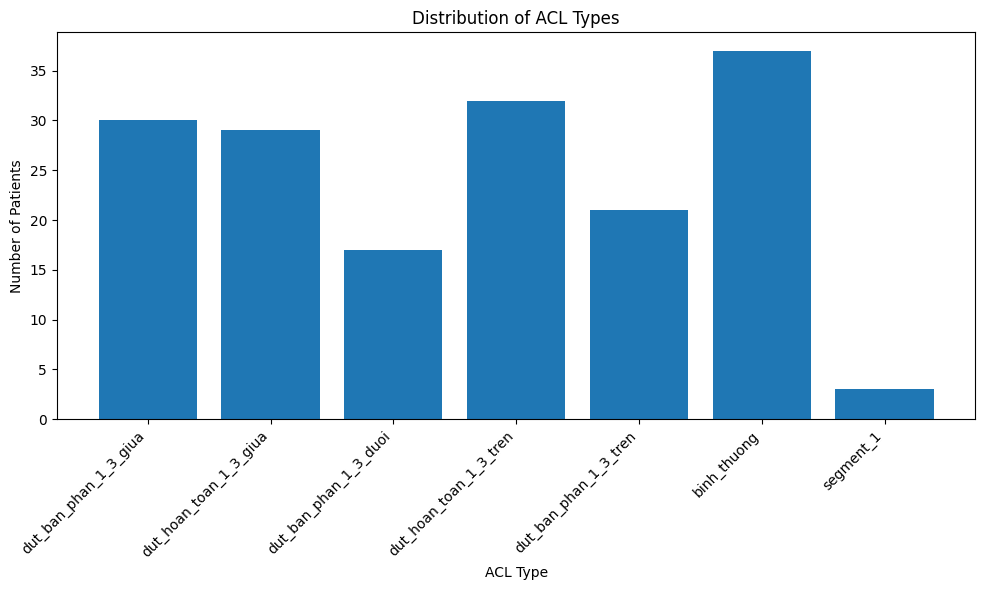

In [21]:

def get_acl_indices(seg_header: dict):
    seg_indices = []
    for k in seg_header.keys():
        m = pattern.match(k)
        if m:
            seg_indices.append(m.group(1))
    return seg_indices
        
def get_acl_type(seg_header: Dict):
    indices = get_acl_indices(seg_header=seg_header)
    for idx in indices:
        tag_key = f"Segment{idx}_Tags"
        name_key = f"Segment{idx}_Name"
        if tag_key in seg_header and name_key in seg_header:
            v = str(seg_header[tag_key])
            if v.startswith(Segment_signal_string):
                return str(seg_header[name_key]).lower()
            
def collect_data_and_seg(root_dir: str) -> Dict:
    root_dir = Path(root_dir)
    result = {}
    for subfolder in root_dir.iterdir():
        if not subfolder.is_dir():
            continue
        seg_files = sorted(subfolder.glob("Segmentation*.seg.nrrd"))
        t2_files = sorted(
            p for p in subfolder.glob("*.nrrd")
            if "t2_tse_sag" in p.stem.lower()
        )
        if not seg_files or not t2_files:
            continue
        _, seg_header = nrrd.read(str(seg_files[0]))
        acl_type = get_acl_type(seg_header=seg_header)
        result[subfolder.name] = {
            "nrrd": str(t2_files[0]),
            "seg": str(seg_files[0]),
            "type": acl_type
        }
    return result
if __name__ =="__main__":
    root_dir=Path("D:\Project\ACL\my_tool\data")
    all_patients = {}
    for sub_folder in root_dir.iterdir():
        if not sub_folder.is_dir():
            continue
        print(sub_folder.name)
        data_dict = collect_data_and_seg(sub_folder)
        all_patients.update(data_dict)

        print(f"number of selected files: {len(data_dict)}")
        for patient, data in data_dict.items():
            print(f"Patient {patient} with ACL type: {data['type']}")

    type_count = {}
    for patient, data in all_patients.items():
        acl_type = data["type"]
        if acl_type is None:
            acl_type = "unknown"
        if acl_type in type_count:
            type_count[acl_type] += 1
        else:
            type_count[acl_type] = 1

    print("\nACL type distribution:")
    print(f"Total patient: {len(all_patients)}")
    for k, v in type_count.items():
        print(f"{k}: {v}")
    # =========================
    # PLOT
    # =========================
    labels = list(type_count.keys())
    counts = list(type_count.values())
    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts)
    plt.xlabel("ACL Type")
    plt.ylabel("Number of Patients")
    plt.title("Distribution of ACL Types")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [26]:
def flip_image(img):
    rotated_image = np.rot90(img, k=3)
    flipped_image = np.fliplr(rotated_image)
    return flipped_image    

def print_image(color_map,num_cols,num_rows,data):
    total_patient=len(data)
    for j, (patient,files) in enumerate(data.items()):
        # print(patient)
        # print(files)
        # print(type(files["nrrd"]), type(files["seg"]))
        nrrd_data, _ = nrrd.read(files['nrrd'])
        seg_data, _ = nrrd.read(files['seg'])
        num_shows=nrrd_data.shape[2]
        if nrrd_data.shape[0]!=seg_data.shape[0]:
            print(f"image size and segmentation size is different")
            total_patient-=1
            continue
        fig=plt.figure(figsize=(8,8))
        for i in range(num_shows):
            img = nrrd_data[:,:,i]
            label = seg_data[:,:,i]   
            flip_img=flip_image(img)
            flip_label=flip_image(label)
            plt.subplot(num_rows, num_cols, i + 1)
            plt.title(f"Slice {i+1}")
            plt.imshow(flip_img, cmap="gray")       # clear grayscale
            plt.imshow(flip_label, cmap=color_map)       # crisp segmentation overlay
            plt.axis("off")
        plt.tight_layout()
        output_dir=os.path.join("./data_output",patient)
        plt.savefig(output_dir)
        plt.close(fig=fig)
    return total_patient
cmap = ListedColormap([
    (0, 0, 0, 0),       # class 0 → transparent
    (1, 0, 0, 0.6),     # class 1 → red
    (1, 1, 0, 0.6),     # class 2 → green
    (1, 0, 0, 0.6)      # class 3 → yellow
])
cols = 5
rows = 5
total_patient=print_image(color_map=cmap,num_cols=cols,num_rows=rows,data=all_patients)
print(f"Tong so ca da duoc dan nhan: {len(all_patients)}")
print(f"Tong so ca co the su dung de train Unet: {total_patient}")

Cai Kim Loc_25210566
{'nrrd': 'D:\\Project\\ACL\\my_tool\\data\\2025_14_11_Thanh\\Cai Kim Loc_25210566\\8 t2_tse_sag.nrrd', 'seg': 'D:\\Project\\ACL\\my_tool\\data\\2025_14_11_Thanh\\Cai Kim Loc_25210566\\Segmentation.seg.nrrd', 'type': 'dut_ban_phan_1_3_giua'}
<class 'str'> <class 'str'>
image size and segmentation size is different
Ha Van Chau_20250507
{'nrrd': 'D:\\Project\\ACL\\my_tool\\data\\2025_14_11_Thanh\\Ha Van Chau_20250507\\15 t2_tse_sag.nrrd', 'seg': 'D:\\Project\\ACL\\my_tool\\data\\2025_14_11_Thanh\\Ha Van Chau_20250507\\Segmentation_1.seg.nrrd', 'type': 'dut_hoan_toan_1_3_giua'}
<class 'str'> <class 'str'>
Le Thi Thuy_25193052
{'nrrd': 'D:\\Project\\ACL\\my_tool\\data\\2025_14_11_Thanh\\Le Thi Thuy_25193052\\8 t2_tse_sag.nrrd', 'seg': 'D:\\Project\\ACL\\my_tool\\data\\2025_14_11_Thanh\\Le Thi Thuy_25193052\\Segmentation.seg.nrrd', 'type': 'dut_ban_phan_1_3_duoi'}
<class 'str'> <class 'str'>
image size and segmentation size is different
Le Van Chung_25938957
{'nrrd': 'D:

In [ ]:
para = {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':2,
        'number_of_fc_layer':2,
        'num_classes':2,
        'conv_channels': [6, 16],
        'fc_feature':[84,2]
    }
model=LeNet(para)

In [90]:

def transform_image(image_np, target_size):
    """
    image_np: 2D numpy array (H, W), dtype can be uint16
    target_size: (H_out, W_out)
    returns: torch.Tensor, shape (1, H_out, W_out), values in [0, 1]
    """
    # 1) Convert to float32 and normalize to 0–1
    image_np = image_np.astype(np.float32)
    min_val = image_np.min()
    max_val = image_np.max()
    image_np = (image_np - min_val) / (max_val - min_val + 1e-8)  # now in [0, 1]
    # 2) Convert to uint8 for PIL (0–255)
    image_uint8 = (image_np * 255).astype(np.uint8)

    # 3) To PIL image
    img = Image.fromarray(image_uint8)   # mode 'L' (grayscale)

    # 4) Geometric transforms
    img = img.rotate(90, expand=True)   # rotate 270°
    img = ImageOps.flip(img)             # vertical flip
    # If you want horizontal flip instead:
    # img = ImageOps.mirror(img)

    # 5) Resize + to tensor (values back to [0, 1])
    preprocess = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),   # -> (1, H, W), values in [0, 1]
    ])

    tensor = preprocess(img)
    return tensor, img


In [91]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.load_state_dict(torch.load('model.pth',weights_only=True))
model.to(device)
model.eval()

Using device: cuda


LeNet(
  (Conv_layer): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 6, kernel_size=(7, 7), stride=(1, 1), padding=(2, 2))
      (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(6, 16, kernel_size=(7, 7), stride=(1, 1), padding=(2, 2))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (FC_layer): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=97344, out_features=84, bias=True)
      (1): ReLU()
      (2): Linear(in_features=84, out_features=2, bias=True)
      (3): Softmax(dim=1)
    )
  )
)

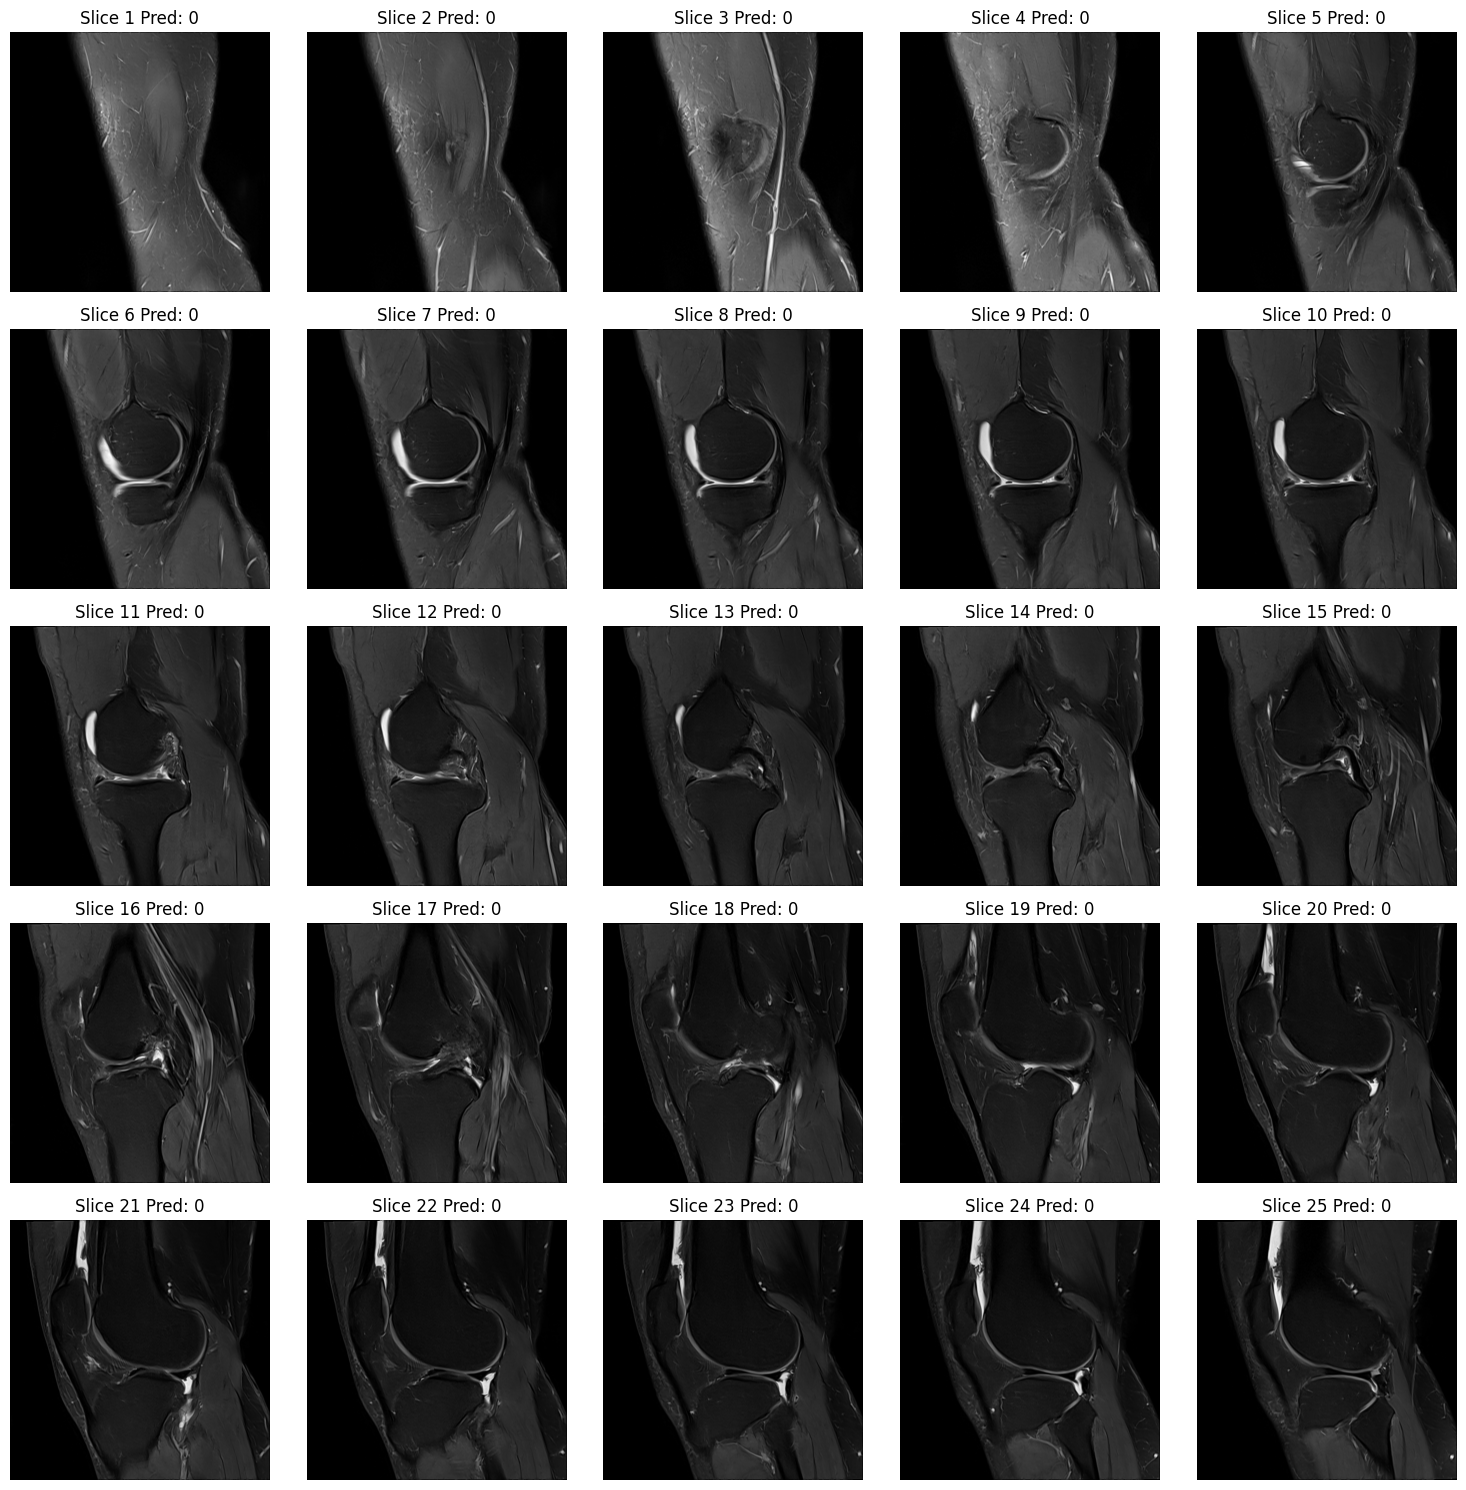

In [92]:
predictions = []
images_for_plot = []
with torch.no_grad():
    for i in range(25):
        slice_np = data[:, :, i]   # uint16 slice

        input_tensor, img_for_plot = transform_image(slice_np, (320, 320))
        images_for_plot.append(img_for_plot)     # keep for visualization
        input_tensor = input_tensor.unsqueeze(0).to(device)  # (1, 1, H, W)
        logits = model(input_tensor)             # model prediction
        pred_label = torch.argmax(logits, dim=1).item()
        predictions.append(pred_label)


# -----------------------------
# Plot (5×5 matrix)
# -----------------------------
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
idx = 0
for r in range(5):
    for c in range(5):
        axes[r, c].imshow(images_for_plot[idx], cmap='gray')
        axes[r, c].set_title(f"Slice {idx+1} Pred: {predictions[idx]}")
        axes[r, c].axis("off")
        idx += 1

plt.tight_layout()
plt.show()